## Object localization & image classification


We would be using the MNIST dataset (numbers from 0-9)
1. Each digit would be placed on a black canvas of width 75x75 at random locations (MNIST has digits on a 28x28 scale)
2. A bounding box would be added on borders of the digit and then the resultant image would be placed on the canvas
3. Corresponding bounding box would be calculated for the digits
4. The dataset would also be changed where the x<sub>i</sub> would be the images of the digits on the canvas & there would be multiple-labels of the digit class & the coordinates of the bounding boxes<br>

This data would be used to train a *regression model* which can predict the coordinates of the bounding boxes <br>
Then the image can be classified using the *classification* task

##### *Object localization* - Finding the exact location of an object in the image
##### *Object detection* - Object localization + multi-label classification (classifying and assigning a class to every object in the image)

In [4]:
!pip install tensorflow
!pip install tensorflow-datasets

In [5]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import PIL.Image, PIL.ImageFont, PIL.ImageDraw

print(f"Tensorflow version {tf.__version__}")

/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Tensorflow version 2.21.0


### Visualization utils

These functions would be used to draw bounding boxes around digits

In [6]:
im_width = 75
im_height = 75
use_normalized_coordinates = True

def draw_bounding_boxes_on_img_array(image, boxes, color=[], thickness=1, display_str_list=()):
    """Draw bounding boxes on the image, with the provided color and line thickness"""
    # Create a pillow image instance from a numpy array
    image_pil = PIL.Image.fromarray(image)
    rgbimg = PIL.Image.new("RGBA", image_pil.size)
    rgbimg.paste(image_pil)
    trigger_bounding_boxes_on_PIL(rgbimg, boxes, color, thickness, display_str_list)
    return np.array(rgbimg)


def trigger_bounding_boxes_on_PIL(image, boxes, color=[], thickness=1, display_str_list=()):
    """
    Draw bounding box on the image where the input is a PIL image object
    This acts as a wrapper which calls the loop for drawing each bounding box on the image
    Input - PIL rgb image]
            Boxes - This is a numpy array of size [N,4] where N is the numnber of boxes to be drawn
                    Each 4 represents 4 co-ordinates (ymin, xmin, ymax, xmax)
    """
    boxes_shape = boxes.shape
    if not boxes_shape:
        return
    if len(boxes_shape) != 2 or boxes_shape[1] != 4:
        raise ValueError('Input must be of size [N, 4]')
    # Wrapper which triggers the bounding boxes drawing loop
    for i in range(boxes_shape[0]):
        draw_actual_bounding_box(image, boxes[i,1], boxes[i,0], boxes[i,3], boxes[i,2], color[i], thickness, display_str_list[i])


def draw_actual_bounding_box(image, ymin, xmin, ymax, xmax, color="red", thickness=1, display_str=None, use_normalized_coordinates=True):
    """Draw the actual bounding box on the image"""
    draw = PIL.ImageDraw.Draw(image)
    im_width, im_height = image.size
    if use_normalized_coordinates:
        (left, right, top, bottom) = (xmin * im_width, xmax * im_width,
                                    ymin * im_height, ymax * im_height)
    else:
        (left, right, top, bottom) = (xmin, xmax, ymin, ymax)
    draw.line([(left,top), (left,bottom), (right,bottom), (right,top), (left,top)], width=thickness, fill=color)

### Visualization utils

Visualizing and downloads only, this includes adding the numbers on a 75x75 canvas and adding bounding boxes

In [7]:
# Matplotlib config
plt.rc('image', cmap='gray')
plt.rc('grid', linewidth=0)
plt.rc('xtick', top=False, bottom=False, labelsize='large')
plt.rc('ytick', left=False, right=False, labelsize='large')
plt.rc('axes', facecolor='F8F8F8', titlesize="large", edgecolor='white')
plt.rc('text', color='a8151a')
plt.rc('figure', facecolor='F0F0F0')# Matplotlib fonts
MATPLOTLIB_FONT_DIR = os.path.join(os.path.dirname(plt.__file__), "mpl-data/fonts/ttf")

# pull a batch from the datasets. This code is not very nice, it gets much better in eager mode (TODO)
def dataset_to_numpy_util(training_dataset, validation_dataset, N):

  # get one batch from each: 10000 validation digits, N training digits
  batch_train_ds = training_dataset.unbatch().batch(N)

  # eager execution: loop through datasets normally
  if tf.executing_eagerly():
    for validation_digits, (validation_labels, validation_bboxes) in validation_dataset:
      validation_digits = validation_digits.numpy()
      validation_labels = validation_labels.numpy()
      validation_bboxes = validation_bboxes.numpy()
      break
    for training_digits, (training_labels, training_bboxes) in batch_train_ds:
      training_digits = training_digits.numpy()
      training_labels = training_labels.numpy()
      training_bboxes = training_bboxes.numpy()
      break

  # these were one-hot encoded in the dataset
  validation_labels = np.argmax(validation_labels, axis=1)
  training_labels = np.argmax(training_labels, axis=1)

  return (training_digits, training_labels, training_bboxes,
          validation_digits, validation_labels, validation_bboxes)

# create digits from local fonts for testing
def create_digits_from_local_fonts(n):
  font_labels = []
  img = PIL.Image.new('LA', (75*n, 75), color = (0,255)) # format 'LA': black in channel 0, alpha in channel 1
  font1 = PIL.ImageFont.truetype(os.path.join(MATPLOTLIB_FONT_DIR, 'DejaVuSansMono-Oblique.ttf'), 25)
  font2 = PIL.ImageFont.truetype(os.path.join(MATPLOTLIB_FONT_DIR, 'STIXGeneral.ttf'), 25)
  d = PIL.ImageDraw.Draw(img)
  for i in range(n):
    font_labels.append(i%10)
    d.text((7+i*75,0 if i<10 else -4), str(i%10), fill=(255,255), font=font1 if i<10 else font2)
  font_digits = np.array(img.getdata(), np.float32)[:,0] / 255.0 # black in channel 0, alpha in channel 1 (discarded)
  font_digits = np.reshape(np.stack(np.split(np.reshape(font_digits, [75, 75*n]), n, axis=1), axis=0), [n, 75*75])
  return font_digits, font_labels


# utility to display a row of digits with their predictions
def display_digits_with_boxes(digits, predictions, labels, pred_bboxes, bboxes, iou, title):
  n = 10

  indexes = np.random.choice(len(predictions), size=n)
  n_digits = digits[indexes]
  n_predictions = predictions[indexes]
  n_labels = labels[indexes]

  n_iou = []
  if len(iou) > 0:
    n_iou = iou[indexes]

  if (len(pred_bboxes) > 0):
    n_pred_bboxes = pred_bboxes[indexes,:]

  if (len(bboxes) > 0):
    n_bboxes = bboxes[indexes,:]


  n_digits = n_digits * 255.0
  n_digits = n_digits.reshape(n, 75, 75)
  fig = plt.figure(figsize=(20, 4))
  plt.title(title)
  plt.yticks([])
  plt.xticks([])

  for i in range(10):
    ax = fig.add_subplot(1, 10, i+1)
    bboxes_to_plot = []
    if (len(pred_bboxes) > i):
      bboxes_to_plot.append(n_pred_bboxes[i])

    if (len(bboxes) > i):
      bboxes_to_plot.append(n_bboxes[i])

    img_to_draw = draw_bounding_boxes_on_img_array(image=n_digits[i], boxes=np.asarray(bboxes_to_plot), color=['red', 'green'], display_str_list=["true", "pred"])
    plt.xlabel(n_predictions[i])
    plt.xticks([])
    plt.yticks([])

    if n_predictions[i] != n_labels[i]:
      ax.xaxis.label.set_color('red')



    plt.imshow(img_to_draw)

    if len(iou) > i :
      color = "black"
      if (n_iou[i][0] < iou_threshold):
        color = "red"
      ax.text(0.2, -0.3, "iou: %s" %(n_iou[i][0]), color=color, transform=ax.transAxes)


# utility to display training and validation curves
def plot_metrics(metric_name, title, ylim=5):
  plt.title(title)
  plt.ylim(0,ylim)
  plt.plot(history.history[metric_name],color='blue',label=metric_name)
  plt.plot(history.history['val_' + metric_name],color='green',label='val_' + metric_name)

### Decide the accelator - TPU vs GPU detection

In [8]:
# Detect hardware
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver() # TPU detection
except ValueError:
    tpu = None
    gpus = tf.config.experimental.list_logical_devices("GPU")


# Select appropriate distribution strategy
if tpu:
  tpu_cluster_resolver = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='local')  # TPU detection
  tf.config.experimental_connect_to_cluster(tpu_cluster_resolver)
  tf.tpu.experimental.initialize_tpu_system(tpu_cluster_resolver)
  print("All devices: ", tf.config.list_logical_devices('TPU'))
  print(f'Running on a TPU w/{tpu_cluster_resolver.num_accelerators()["TPU"]} cores')
  strategy = tf.distribute.TPUStrategy(tpu_cluster_resolver)
elif len(gpus) > 1:
  strategy = tf.distribute.MirroredStrategy([gpu.name for gpu in gpus])
  print('Running on multiple GPUs ', [gpu.name for gpu in gpus])
elif len(gpus) == 1:
  strategy = tf.distribute.get_strategy() # default strategy that works on CPU and single GPU
  print('Running on single GPU ', gpus[0].name)
else:
  strategy = tf.distribute.get_strategy() # default strategy that works on CPU and single GPU
  print('Running on CPU')
print("Number of accelerators: ", strategy.num_replicas_in_sync)

Running on CPU
Number of accelerators:  1


### Parameters

The global parameters which would be used for model creation & training

In [9]:
# Global batch size
BATCH_SIZE = 64 * strategy.num_replicas_in_sync

# The global batch size will be automatically sharded across all
# replicas by the tf.data.Dataset API. A single TPU has 8 cores.
# The best practice is to scale the batch size by the number of
# replicas (cores). The learning rate should be increased as well.

## Main AI game starts here

### Loading and pre-processing data

Define some helper functions that will pre-process your data:
- `read_image_tfds`: Randomly overlays the "digit" image on top of a larger canvas (75x75 in this case)
- `get_training_dataset`: Loads data and splits it to get the training set.
- `get_validation_dataset`: Loads and splits the data to get the validation set.

In [10]:
# Transforms the dataset by pasting the image on a 75x75 canvas
def read_image_tfds(image, label):
    # 0-48 since the image is 28x28 and shouldn't go out of bounds on the canvas
    xmin = tf.random.uniform((), 0, 48, dtype=tf.int32)
    ymin = tf.random.uniform((), 0, 48, dtype=tf.int32)
    # Reshape to 28x28 if somehow the image isn't of the size
    image = tf.reshape(image, (28,28,1))
    # Fills the remaining space with 0s' (black color)
    # Usage - image, offset_height, offset_width, target_height, target_width
    image = tf.image.pad_to_bounding_box(image, ymin, xmin, 75, 75)
    image = tf.cast(image, tf.float32)/255.0
    xmin = tf.cast(xmin, tf.float32)
    ymin = tf.cast(ymin, tf.float32)

    # Normalized bounding box coordinates
    xmax = (xmin + 28)/75
    ymax = (ymin + 28)/75
    xmin = xmin / 75
    ymin = ymin / 75
    return image, (tf.one_hot(label, 10), [xmin, ymin, xmax, ymax])

# Loads the training dataset
def get_training_dataset():
    with strategy.scope():
        dataset = tfds.load("mnist", split="train", as_supervised=True, try_gcs=True)
        dataset = dataset.map(read_image_tfds, num_parallel_calls = 16)
        dataset = dataset.shuffle(5000, reshuffle_each_iteration=True)
        dataset = dataset.repeat()
        dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)
        # fetch next batches while training on the current one (-1: autotune prefetch buffer size)
        dataset = dataset.prefetch(-1)
    return dataset

def get_validation_dataset():
    dataset = tfds.load("mnist", split="test", as_supervised=True, try_gcs=True)
    dataset = dataset.map(read_image_tfds, num_parallel_calls = 16)
    dataset = dataset.batch(10000, drop_remainder=True)
    dataset = dataset.repeat()
    return dataset

with strategy.scope():
    training_dataset = get_training_dataset()
    validation_dataset = get_validation_dataset()

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.NBWB34_3.0.1/mnist-train.tfrecord-[0-9][0-9][0-9][0-9][0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.NBWB34_3.0.1/mnist-test.tfrecord-[0-9][0-9][0-9][0-9][0-9…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


### Visualize the dataset

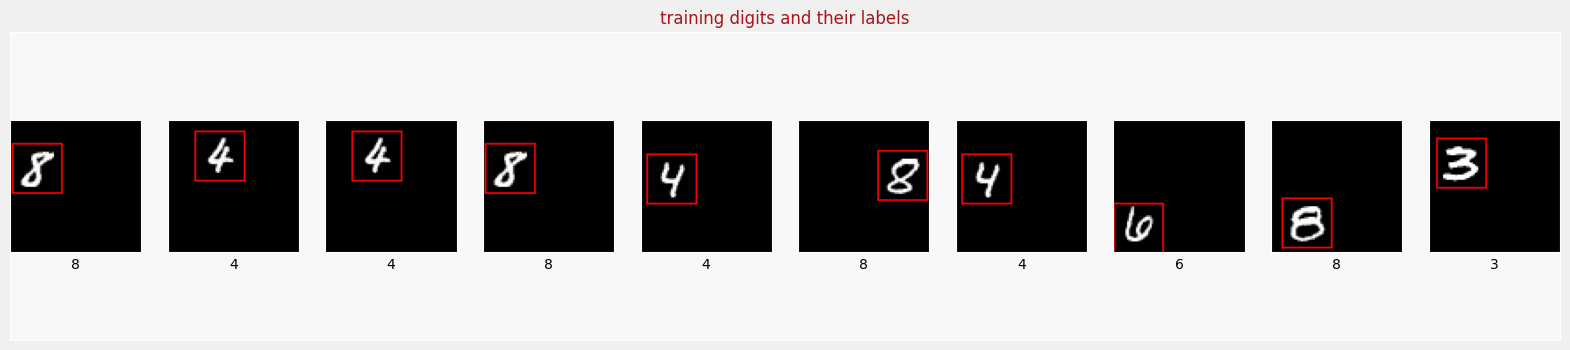

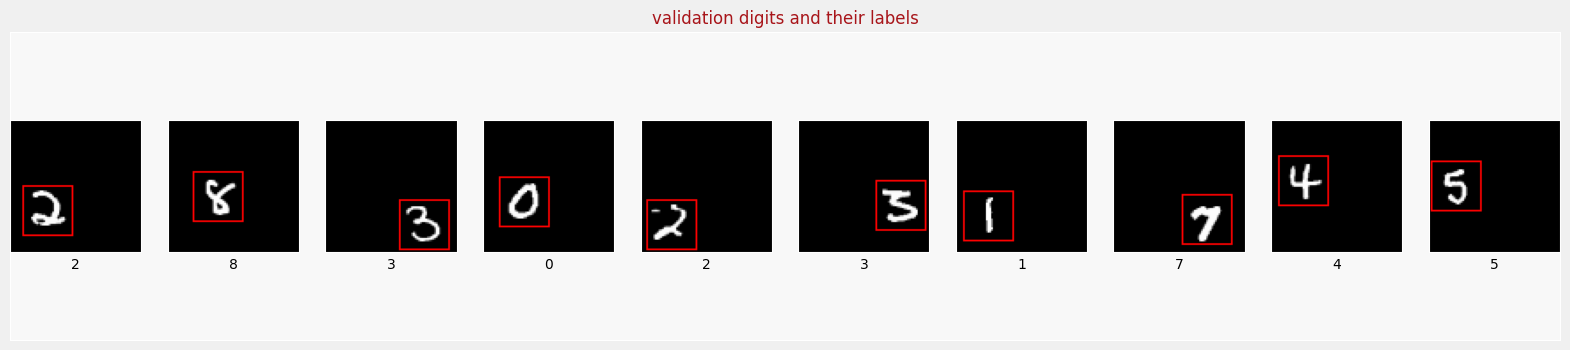

In [11]:
# Above we wrote the functions to get the training and validation datasets and their bound box coordinates (xmin, ymin, xmax, ymax) which are passed as inputs to the functions
(training_digits, training_labels, training_bboxes,
    validation_digits, validation_labels, validation_bboxes) = dataset_to_numpy_util(training_dataset, validation_dataset, 10)

display_digits_with_boxes(training_digits, training_labels, training_labels, np.array([]), training_bboxes, np.array([]), "training digits and their labels")
display_digits_with_boxes(validation_digits, validation_labels, validation_labels, np.array([]), validation_bboxes, np.array([]), "validation digits and their labels")

## Define the Network - Functional API in keras

Multi-output model -

- `feature_extractor`: these convolutional layers extract the features of the image.
- `classifier`:  This define the output layer that predicts among 10 categories (digits 0 through 9)
- `bounding_box_regression`: This defines the output layer that predicts 4 numeric values, which define the coordinates of the bounding box (xmin, ymin, xmax, ymax)
- `final_model`: This combines the layers for feature extraction, classification and bounding box prediction.  
  - Notice that this is another example of a branching model, because the model splits to produce two kinds of output (a category and set of numbers).  
  - Since you've learned to use the Functional API earlier in the specialization (course 1), you have the flexibility to define this kind of branching model!
- `define_and_compile_model`: choose the optimizer and metrics, then compile the model.

In [12]:
# Feature extractor which is a Convolutional network
def feature_extractor(inputs):
    x = tf.keras.layers.Conv2D(16, kernel_size=3, activation='relu', input_shape=(75,75,1))(inputs)
    x = tf.keras.layers.AveragePooling2D((2,2))(x)

    x = tf.keras.layers.Conv2D(32, kernel_size=3, activation="relu")(x)
    x = tf.keras.layers.AveragePooling2D((2,2))(x)

    x = tf.keras.layers.Conv2D(64, kernel_size=3, activation="relu")(x)
    x = tf.keras.layers.AveragePooling2D((2,2))(x)
    return x

# This will follow the feature extraction layers
def dense_layers(inputs):
    x = tf.keras.layers.Flatten()(inputs)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    return x

# This will come after the dense layers and will predict the class (digits)
#  Fully connected layers which will predict a class out of 10 (digits 0->9)
def classifier(inputs):
    classification_output = tf.keras.layers.Dense(10, activation="softmax", name="classification")(inputs)
    return classification_output

def bounding_box_regression(inputs):
    bounding_box_regression_output = tf.keras.layers.Dense(units=4, name="bounding_box")(inputs)
    return bounding_box_regression_output

def final_model(inputs):
    feature_cnn = feature_extractor(inputs)
    dense_output = dense_layers(feature_cnn)
    # Model branches here into 2 outputs
    classification_output = classifier(dense_output)
    bounding_box_output = bounding_box_regression(dense_output)
    model = tf.keras.Model(inputs=inputs, outputs=[classification_output, bounding_box_output])
    return model

def define_and_compile_model(inputs):
    model = final_model(inputs)
    model.compile(optimizer='adam',
                    loss={'classification': 'categorical_crossentropy',
                    'bounding_box': 'mse'},
                    metrics={'classification': 'accuracy', 'bounding_box':'mse'})
    return model

with strategy.scope():
    inputs=tf.keras.layers.Input(shape=(75, 75, 1))
    model = define_and_compile_model(inputs)

# Check the model structure
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 75, 75, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 73, 73,    │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 36, 36,    │          0 │ conv2d[0][0]      │
│ (AveragePooling2D)  │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 34, 34,    │      4,640 │ average_pooling2… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_1 │ (None, 17, 17,    │          0 │ conv2d_1[0][0]    │
│ (AveragePooling2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 15, 15,    │     18,496 │ average_pooling2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_2 │ (None, 7, 7, 64)  │          0 │ conv2d_2[0][0]    │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 10)        │      1,290 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bounding_box        │ (None, 4)         │        516 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 426,638 (1.63 MB)

 Trainable params: 426,638 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

### Train & validate the model

In [13]:
EPOCHS = 10 # 45
steps_per_epoch = 60000//BATCH_SIZE  # 60,000 items in this dataset
validation_steps = 1

history = model.fit(training_dataset,
                    steps_per_epoch=steps_per_epoch, validation_data=validation_dataset, validation_steps=validation_steps, epochs=EPOCHS)

loss, classification_loss, bounding_box_loss, classification_accuracy, bounding_box_mse = model.evaluate(validation_dataset, steps=1)
print("Validation accuracy: ", classification_accuracy)

Epoch 1/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 79s 83ms/step - bounding_box_loss: 0.0152 - bounding_box_mse: 0.0152 - classification_accuracy: 0.6669 - classification_loss: 0.9508 - loss: 0.9660 - val_bounding_box_loss: 0.0094 - val_bounding_box_mse: 0.0094 - val_classification_accuracy: 0.9100 - val_classification_loss: 0.2945 - val_loss: 0.3039
Epoch 2/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 75s 80ms/step - bounding_box_loss: 0.0065 - bounding_box_mse: 0.0065 - classification_accuracy: 0.9212 - classification_loss: 0.2566 - loss: 0.2631 - val_bounding_box_loss: 0.0042 - val_bounding_box_mse: 0.0042 - val_classification_accuracy: 0.9441 - val_classification_loss: 0.1832 - val_loss: 0.1875
Epoch 3/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 75s 80ms/step - bounding_box_loss: 0.0037 - bounding_box_mse: 0.0037 - classification_accuracy: 0.9436 - classification_loss: 0.1861 - loss: 0.1898 - val_bounding_box_loss: 0.0032 - val_bounding_box_mse: 0.0032 - val_classification_accuracy: 0.9545 - val_classification_loss: 

### IOU - Intersection Over Union

Calculate the IOU (Intersection Over Union) to evaluate the model's performance

`smoothing_factor` - A small value which is used to prevent division by zero

In [17]:
def iou_score(pred_box, true_box):
    # Split the coordinates into the 4 vertices of the bounding box
    xmin_pred, ymin_pred, xmax_pred, ymax_pred =  np.split(pred_box, 4, axis = 1)
    xmin_true, ymin_true, xmax_true, ymax_true = np.split(true_box, 4, axis = 1)

    smoothing_factor = 1e-10
    xmin_overlap = np.maximum(xmin_pred, xmin_true)
    ymin_overlap = np.maximum(ymin_pred, ymin_true)
    xmax_overlap = np.minimum(xmax_pred, xmax_true)
    ymax_overlap = np.minimum(ymax_pred, ymax_true)

    pred_box_area = (xmax_pred - xmin_pred) * (ymax_pred - ymin_pred)
    true_box_area = (xmax_true - xmin_true) * (ymax_true - ymin_true)
    overlap_area = np.maximum((xmax_overlap - xmin_overlap), 0)  * np.maximum((ymax_overlap - ymin_overlap), 0)
    union_area = (pred_box_area + true_box_area) - overlap_area

    iou = (overlap_area + smoothing_factor) / (union_area + smoothing_factor)
    return iou


### Visualize predictions

- The true bounding box will be in green
- Model's predicted bounding box will be in red
- The predicted class will be shown below the image

157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step
Number of predictions where iou > threshold(0.6): 9394
Number of predictions where iou < threshold(0.6): 606


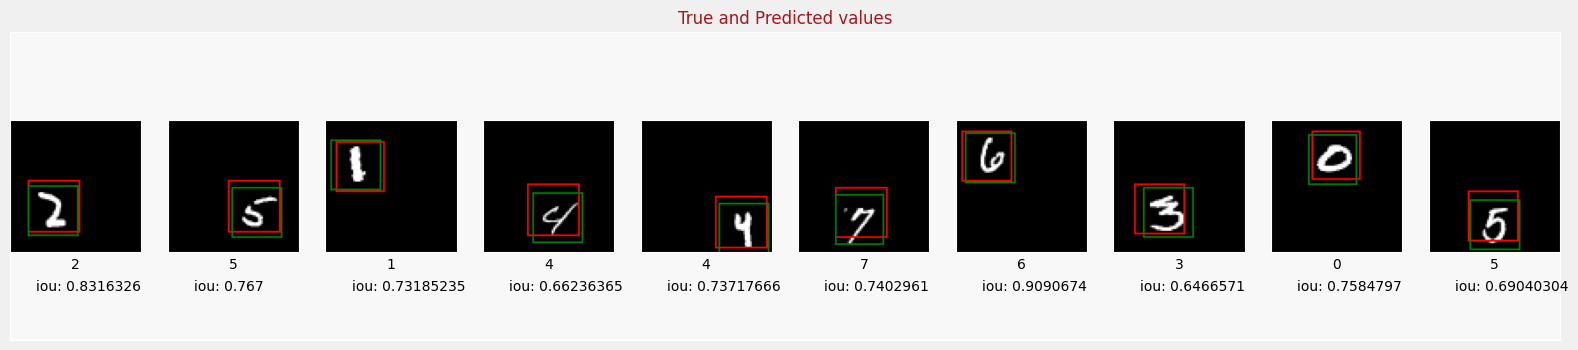

In [18]:
predictions = model.predict(validation_digits, batch_size=64)
predicted_labels = np.argmax(predictions[0], axis=1)
predicted_bboxes = predictions[1]

iou = iou_score(predicted_bboxes, validation_bboxes)
iou_threshold = 0.6

print("Number of predictions where iou > threshold(%s): %s" % (iou_threshold, (iou >= iou_threshold).sum()))
print("Number of predictions where iou < threshold(%s): %s" % (iou_threshold, (iou < iou_threshold).sum()))


display_digits_with_boxes(validation_digits, predicted_labels, validation_labels, predicted_bboxes, validation_bboxes, iou, "True and Predicted values")